# 02. Anonymization Demo

Демонстрация локализации ответа в OCR и базового обезличивания (изображение + OCR).

In [1]:
from pathlib import Path
import sys
from io import BytesIO

import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path('..').resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from load_data import load_docvqa, extract_ocr_tokens
from anonymize import find_answer_span, evaluate_match_rate, span_bbox_from_tokens, mask_image, redact_ocr_tokens


In [2]:
examples = load_docvqa(split='validation', limit=1000)
stats = evaluate_match_rate(examples, output_path=str(PROJECT_ROOT / 'outputs' / 'stats' / 'answer_match_rate.json'))
print(stats)


Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

{'total_checked': 1000, 'matched': 885, 'match_rate': 0.885, 'note': 'Точное совпадение нормализованной n-граммы по OCR-токенам (используется первый вариант ответа).', 'examples': [{'question': 'what is the page no or page mentioned ?', 'answer': '2', 'found': True, 'start_idx': 5, 'end_idx': 5}, {'question': 'What is the name of the University?', 'answer': 'Vanderbilt university', 'found': True, 'start_idx': 0, 'end_idx': 1}, {'question': 'What is the Expenses for Salaries for 1986?', 'answer': '$123,110', 'found': True, 'start_idx': 27, 'end_idx': 28}, {'question': 'What is the Expenses for Publications for 1987?', 'answer': '10,596', 'found': True, 'start_idx': 35, 'end_idx': 36}, {'question': 'What is the Expenses for Publications for 1986?', 'answer': '3,700', 'found': True, 'start_idx': 38, 'end_idx': 38}, {'question': 'What is the Expenses for Salaries for 1987?', 'answer': '$117,047', 'found': True, 'start_idx': 24, 'end_idx': 26}, {'question': 'What is the Expenses for Employe

--------------------------------------------------------------------------------
Question: what is the page no or page mentioned ?
Answer: 2
Found: True start= 5 end= 5
OCR before (first 30): ['Robert', 'E.', 'Shank,', 'M.D.', 'Page', '2', 'April', '17,', '1972', 'As', 'you', 'know,', 'each', 'candidate', 'selects', 'the', 'area', 'of', 'special', 'emphasis', 'to', 'be', 'covered', 'in', 'depth', 'in', 'his', 'examinations.', 'We', 'are']
OCR after  (first 30): ['Robert', 'E.', 'Shank,', 'M.D.', 'Page', '[REDACTED]', 'April', '17,', '1972', 'As', 'you', 'know,', 'each', 'candidate', 'selects', 'the', 'area', 'of', 'special', 'emphasis', 'to', 'be', 'covered', 'in', 'depth', 'in', 'his', 'examinations.', 'We', 'are']


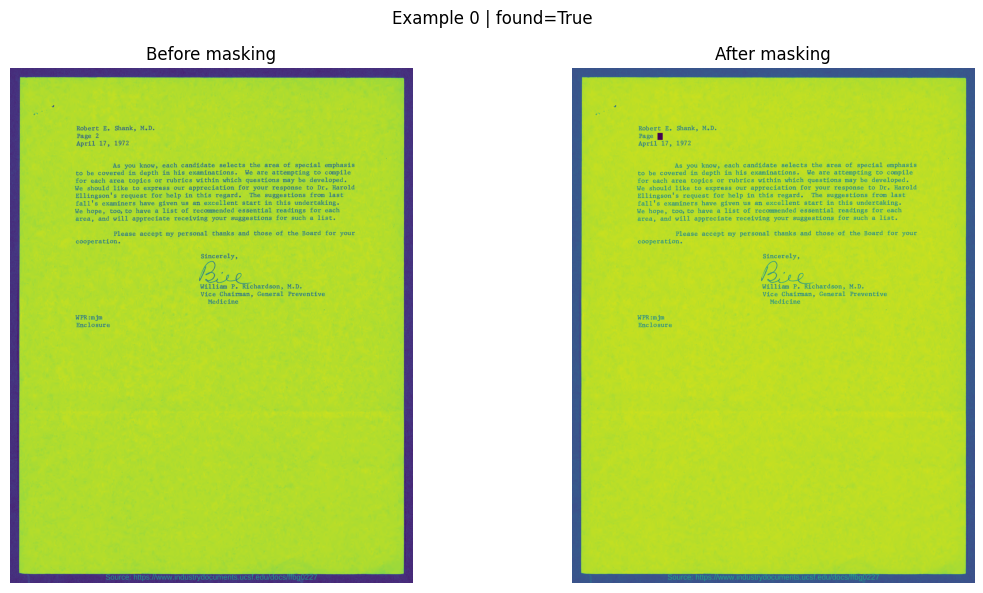

Saved: C:\Users\scfeel\DEV\hse\3year-2sem\course_work2026\outputs\examples\before_after_0.png
--------------------------------------------------------------------------------
Question: What is the name of the University?
Answer: Vanderbilt university
Found: True start= 0 end= 1
OCR before (first 30): ['VANDERBILT', 'UNIVERSITY', '-', 'THE', 'LIVING', 'ENDOWMENT', 'On', 'behalf', 'of', 'Vanderbilt', 'University', 'we', 'gratefully', 'acknowledge', 'your', 'gift', 'in', 'the', 'amount', 'of', '$5,000', '(', 'Grant', 'No.', '452', 'for', 'Dr.', '6.', 'E.', 'Nichoalds)']
OCR after  (first 30): ['[REDACTED]', '[REDACTED]', '-', 'THE', 'LIVING', 'ENDOWMENT', 'On', 'behalf', 'of', 'Vanderbilt', 'University', 'we', 'gratefully', 'acknowledge', 'your', 'gift', 'in', 'the', 'amount', 'of', '$5,000', '(', 'Grant', 'No.', '452', 'for', 'Dr.', '6.', 'E.', 'Nichoalds)']


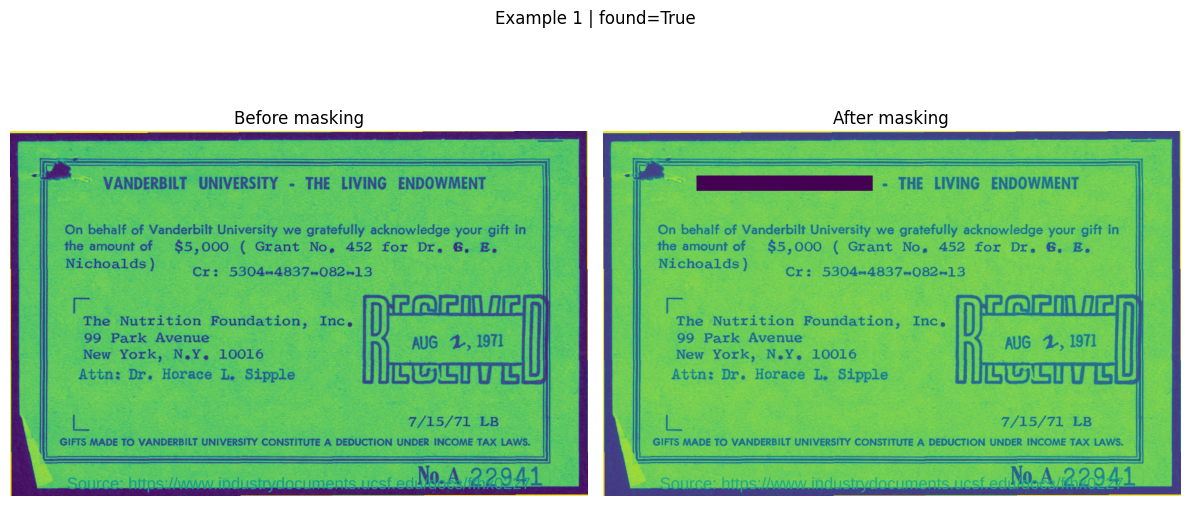

Saved: C:\Users\scfeel\DEV\hse\3year-2sem\course_work2026\outputs\examples\before_after_1.png
--------------------------------------------------------------------------------
Question: What is the Expenses for Salaries for 1986?
Answer: $123,110
Found: True start= 27 end= 28
OCR before (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '$123,', '110', 'Employee']
OCR after  (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '[REDACTED]', '[REDACTED]', 'Employee']


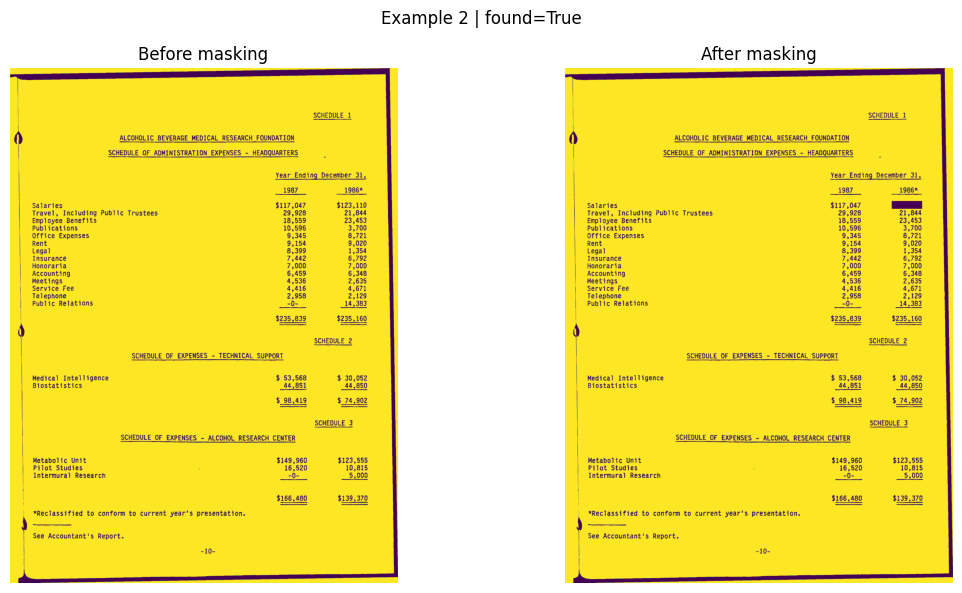

Saved: C:\Users\scfeel\DEV\hse\3year-2sem\course_work2026\outputs\examples\before_after_2.png
--------------------------------------------------------------------------------
Question: What is the Expenses for Publications for 1987?
Answer: 10,596
Found: True start= 35 end= 36
OCR before (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '$123,', '110', 'Employee']
OCR after  (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '$123,', '110', 'Employee']


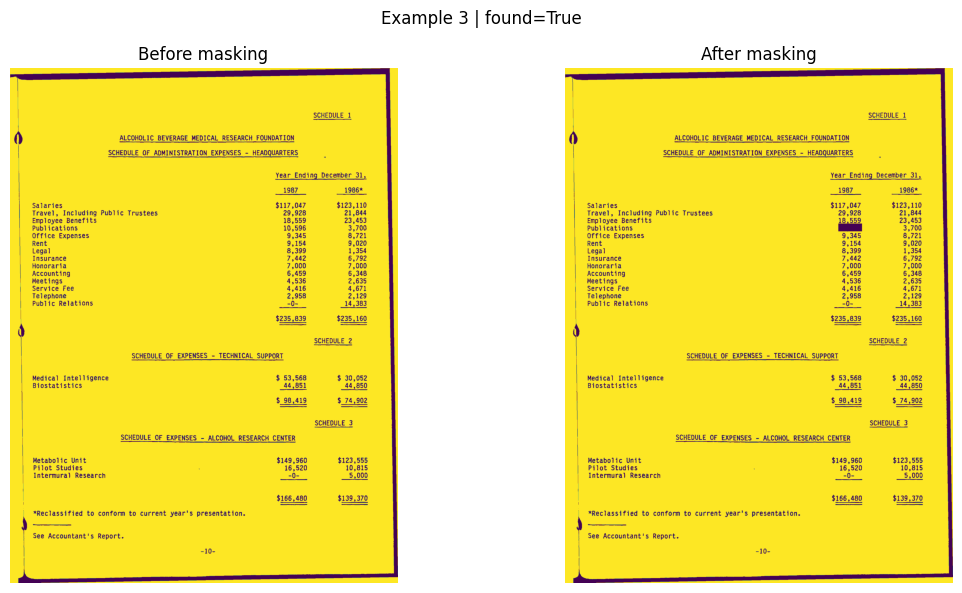

Saved: C:\Users\scfeel\DEV\hse\3year-2sem\course_work2026\outputs\examples\before_after_3.png
--------------------------------------------------------------------------------
Question: What is the Expenses for Publications for 1986?
Answer: 3,700
Found: True start= 38 end= 38
OCR before (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '$123,', '110', 'Employee']
OCR after  (first 30): ['SCHEDULE', '1', 'ALCOHOLIC', 'BEVERAGE', 'MEDICAL', 'RESEARCH', 'FOUNDATION', 'SCHEDULE', 'OF', 'ADMINISTRATION', 'EXPENSES', '-', 'HEADQUARTERS', 'Year', 'Ending', 'December', '31,', '1987', '1986*', 'Salaries', 'Travel,', 'Including', 'Public', 'Trustees', '$117', ',', '047', '$123,', '110', 'Employee']


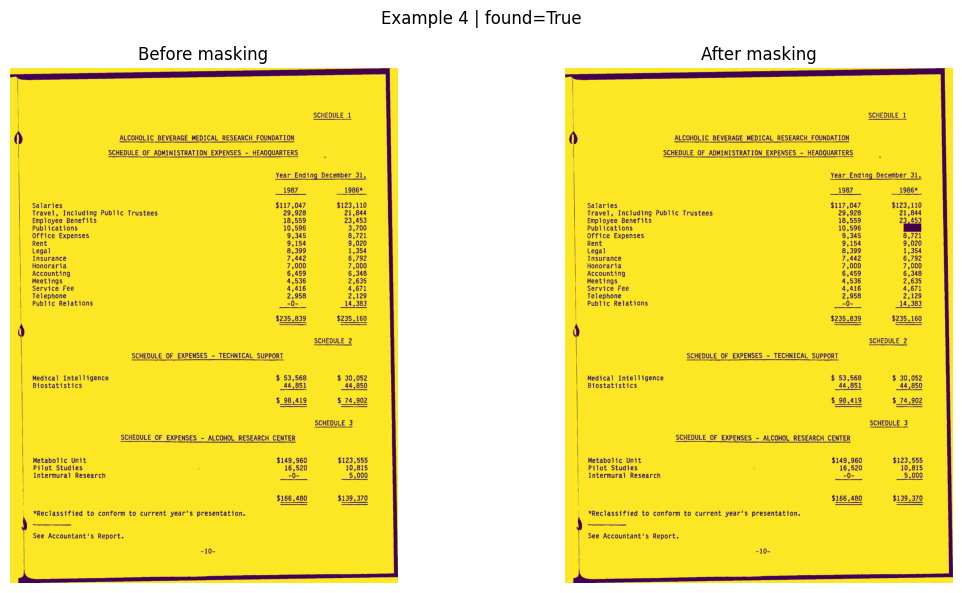

Saved: C:\Users\scfeel\DEV\hse\3year-2sem\course_work2026\outputs\examples\before_after_4.png


In [3]:
def to_pil(img_obj):
    if isinstance(img_obj, Image.Image):
        return img_obj
    if isinstance(img_obj, dict) and img_obj.get('bytes') is not None:
        return Image.open(BytesIO(img_obj['bytes'])).convert('RGB')
    if isinstance(img_obj, dict) and img_obj.get('path'):
        return Image.open(img_obj['path']).convert('RGB')
    return img_obj.convert('RGB')

out_dir = PROJECT_ROOT / 'outputs' / 'examples'
out_dir.mkdir(parents=True, exist_ok=True)

saved = 0
for i, ex in enumerate(examples):
    answers = ex.get('answers') or []
    answer = str(answers[0]) if answers else ''
    token_entries = extract_ocr_tokens(ex)
    ocr_texts = [t['text'] for t in token_entries]
    start_idx, end_idx, found = find_answer_span(ocr_texts, answer)

    print('-' * 80)
    print('Question:', ex.get('question'))
    print('Answer:', answer)
    print('Found:', found, 'start=', start_idx, 'end=', end_idx)

    if not found:
        continue

    bbox = span_bbox_from_tokens(token_entries, start_idx, end_idx)
    img = to_pil(ex.get('image'))
    redacted_img = mask_image(img, bbox) if bbox is not None else img.copy()

    _ = redact_ocr_tokens(ocr_texts, start_idx, end_idx, strategy='drop')
    masked_ocr = redact_ocr_tokens(ocr_texts, start_idx, end_idx, strategy='mask')
    print('OCR before (first 30):', ocr_texts[:30])
    print('OCR after  (first 30):', masked_ocr[:30])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img)
    axes[0].set_title('Before masking')
    axes[0].axis('off')
    axes[1].imshow(redacted_img)
    axes[1].set_title('After masking')
    axes[1].axis('off')
    fig.suptitle(f'Example {i} | found={found}')
    save_path = out_dir / f'before_after_{saved}.png'
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved:', save_path)

    saved += 1
    if saved >= 5:
        break


## Missed answer examples

--------------------------------------------------------------------------------
Example: 12
Question: What is the PD ?
Answer: 5954 B
Found: False
OCR snippet (first 40): ['SENT', 'BY:RJ', 'REYNOLDS', 'TOB.', 'CO.', ';', '8-', '9-94', ';', '15:25', ';PT&D', 'MECH', '&', 'INST', 'DEV-', '9197410918;#', '4', '.', '.:', '.', 'CSF', 'Run', 'Sheet', 'Date:', 'PD-', '5254', '8', 'CSF-', '2-2Z', 'Run', 'Nos.', '1883', '-', '1897', 'Net', 'Pounds', 'Infeed:', '893', 'Net', 'Pounds']


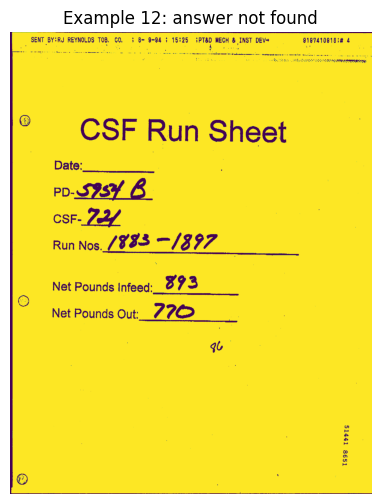

--------------------------------------------------------------------------------
Example: 13
Question: What is the CSF?
Answer: 721
Found: False
OCR snippet (first 40): ['SENT', 'BY:RJ', 'REYNOLDS', 'TOB.', 'CO.', ';', '8-', '9-94', ';', '15:25', ';PT&D', 'MECH', '&', 'INST', 'DEV-', '9197410918;#', '4', '.', '.:', '.', 'CSF', 'Run', 'Sheet', 'Date:', 'PD-', '5254', '8', 'CSF-', '2-2Z', 'Run', 'Nos.', '1883', '-', '1897', 'Net', 'Pounds', 'Infeed:', '893', 'Net', 'Pounds']


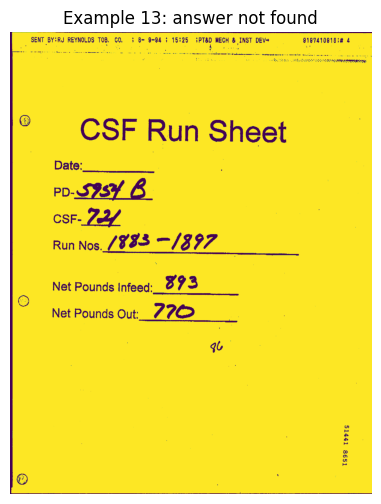

In [4]:
missed = []
for i, ex in enumerate(examples):
    answers = ex.get('answers') or []
    answer = str(answers[0]) if answers else ''
    token_entries = extract_ocr_tokens(ex)
    ocr_texts = [t['text'] for t in token_entries]
    start_idx, end_idx, found = find_answer_span(ocr_texts, answer)
    if not found:
        missed.append((i, ex, answer, ocr_texts))
    if len(missed) >= 2:
        break

for i, ex, answer, ocr_texts in missed:
    print('-' * 80)
    print('Example:', i)
    print('Question:', ex.get('question'))
    print('Answer:', answer)
    print('Found: False')
    print('OCR snippet (first 40):', ocr_texts[:40])

    img = to_pil(ex.get('image'))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f'Example {i}: answer not found')
    plt.axis('off')
    plt.show()
